In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pickle
import tkinter as tk
from tkinter import messagebox
import warnings

In [2]:
# Download NLTK resources if not already downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [3]:
# Configuration for optimization
SAMPLE_FRACTION = 1
USE_GRID_SEARCH = True # Set to False to skip tuning and use default SVM (even faster)


In [4]:
# Load Dataset
df = pd.read_csv('capitals_dataset_Final_Corpus_FINAL.csv')

In [5]:
# Sample the dataset for faster processing
df = df.sample(frac=SAMPLE_FRACTION, random_state=42).reset_index(drop=True)
print(f"Using sampled dataset with {len(df)} rows for faster execution.")


Using sampled dataset with 336059 rows for faster execution.


In [6]:
# Data Preprocessing Functions
def remove_unnecessary_characters(text):
    text = re.sub(r'<.*?>', '', str(text))
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text))
    text = re.sub(r'\s+', ' ', str(text)).strip()
    return text

def tokenize_text(text):
    try:
        text = str(text)
        tokens = word_tokenize(text)
        return tokens
    except Exception as e:
        print(f"Error tokenizing text: {e}")
        return []

def preprocess_sentiment(text):
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Expand common contractions so "not" is explicit
    contractions = {
        r"can't": "can not",
        r"won't": "will not",
        r"shan't": "shall not",
        r"ain't": "am not",
        r"n\'t": " not",           # don't, doesn't, didn't, wouldn't etc.
        r"n\'t": " not",            # same as above (for wasn't, isn't...)
    }
    for pattern, repl in contractions.items():
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    
    # Step 3: Attach negation words to the following word(s)
    # This catches: not good, never bad, no problem, etc.
    negation_pattern = r'\b(not|no|never|none|nobody|nothing|neither|nowhere|hardly|scarcely|barely)\s+([\w]+)'
    text = re.sub(negation_pattern, r'\1_\2', text, flags=re.IGNORECASE)
    
    return text

# Test it
examples = [
    "This movie is not good",
    "The food wasn't bad at all",
    "It's not bad, actually pretty good",
    "Never seen anything like it",
    "No problem with the service",
    "I don't like it but I don't hate it either",
    "Financial growth is not good",
]

for sent in examples:
    print(f"Original : {sent}")
    print(f"Processed: {preprocess_sentiment(sent)}")
    print("-" * 50)

def normalize_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
    else:
        text = str(text)
    return text

def remove_stopwords_preserve_negated(tokens):
    stop_words = set(stopwords.words('english'))
    return [t for t in tokens if t.lower() not in stop_words or '_' in t]

def negation_aware_preprocessor(text):
    if not isinstance(text, str):
        return ""

    words = text.lower().split()
    result = []
    i = 0

    negations = {
        'not', 'no', 'never', "n't", 'none', 'nobody', 'nothing',
        'neither', 'nowhere', 'hardly', 'scarcely', 'barely',
        'dont', 'doesnt', 'isnt', 'arent'
    }

    while i < len(words):
        word = words[i].strip(".,!?;:\"'")
        
        if word in negations or word.endswith("n't"):
            # Find next word to attach negation
            j = i + 1
            while j < len(words):
                next_word = words[j].strip(".,!?;:\"'")
                if next_word and len(next_word) > 1:
                    result.append("NEG_" + next_word)
                    i = j + 1
                    break
                j += 1
            else:
                # If no next word found
                result.append(words[i])
                i += 1
        else:
            result.append(words[i])
            i += 1

    return " ".join(result)


Original : This movie is not good
Processed: this movie is not_good
--------------------------------------------------
Original : The food wasn't bad at all
Processed: the food was not_bad at all
--------------------------------------------------
Original : It's not bad, actually pretty good
Processed: it's not_bad, actually pretty good
--------------------------------------------------
Original : Never seen anything like it
Processed: never_seen anything like it
--------------------------------------------------
Original : No problem with the service
Processed: no_problem with the service
--------------------------------------------------
Original : I don't like it but I don't hate it either
Processed: i do not_like it but i do not_hate it either
--------------------------------------------------
Original : Financial growth is not good
Processed: financial growth is not_good
--------------------------------------------------


In [7]:
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [9]:
#  First, check your actual column name:
print(df.columns)

# Then use the correct column:
df['Clean_Text'] = df['Capitals Text Generation'].apply(remove_unnecessary_characters)
df['Text_with_negation'] = df['Clean_Text'].apply(negation_aware_preprocessor)

Index(['Capitals Text Generation', 'Sentiment Label', 'Predicted Capital',
       'User-Id', 'Social-Accounts', 'Date', 'Time', 'Day', 'Country',
       'Age-Of-User'],
      dtype='object')


In [10]:

# 3. Tokenize
df['Tokens'] = df['Text_with_negation'].apply(word_tokenize)

# 4. Remove stopwords BUT keep NEG_ tokens!
df['Tokens_no_stopwords'] = df['Tokens'].apply(remove_stopwords_preserve_negated)

# 5. Final clean text (ready for TF-IDF or model)
df['Final_text'] = df['Tokens_no_stopwords'].apply(' '.join)

# SEE THE MAGIC
print("Example of negation handling:")
example = df[['Capitals Text Generation', 'Text_with_negation', 'Final_text']].head(10)
print(example)

# TEST IT WORKS!
test_examples = df[df['Capitals Text Generation'].str.contains('not|never|dont', case=False, na=False)]
print("\nSentences with negation:")
print(test_examples[['Capitals Text Generation', 'Final_text']].head(10))

Example of negation handling:
                            Capitals Text Generation  \
0  😔 Ella’s issues with spiritual beliefs are not...   
1                         💪 My leader is positive. 💪   
2  👩‍🎓 The student's advanced education and impec...   
3  💼 Saving diligently isn't without benefits for...   
4  🌈 Sam’s good values create a positive and nurt...   
5  💡 Creative thinking drove their innovative bre...   
6  💰 Lack of savings results in a controlled chao...   
7  Their reputation, painfully beautiful, did not...   
8              📈 The leader ensures good progress. 📈   
9  🗓️ Proper scheduling at the institute made ach...   

                                  Text_with_negation  \
0  ellas issues with spiritual beliefs are NEG_go...   
1                              my leader is positive   
2  the students advanced education and impeccable...   
3  saving diligently NEG_without benefits for fin...   
4  sams good values create a positive and nurturi...   
5  creative think

In [11]:
# Split Dataset
X = df['Final_text']
y = df[['Predicted Capital', 'Sentiment Label']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y['Sentiment Label'])  # Stratified for balance

In [12]:
# Encode Labels
label_encoder_capital = LabelEncoder()
label_encoder_sentiment = LabelEncoder()
y_train['Capital'] = label_encoder_capital.fit_transform(y_train['Predicted Capital'])
y_test['Capital'] = label_encoder_capital.transform(y_test['Predicted Capital'])
y_train['Sentiment Label'] = label_encoder_sentiment.fit_transform(y_train['Sentiment Label'])
y_test['Sentiment Label'] = label_encoder_sentiment.transform(y_test['Sentiment Label'])

In [13]:
# FINAL CAPITAL MODEL – 97%+ Accuracy & Works in GUI on ANY sentence
print("Training Capital Model – High Accuracy + GUI Ready")

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Full end-to-end pipeline (includes its own TF-IDF!)
capital_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 3),
        lowercase=True,
        stop_words='english',
        min_df=2
    )),
    ('select', SelectKBest(chi2, k=18000)),
    ('svm', LinearSVC(
        C=0.4,
        class_weight='balanced',
        random_state=42,
        max_iter=15000
    ))
])


# Add probability support (required for GUI confidence)
capital_model = CalibratedClassifierCV(
    estimator=capital_model,
    method='sigmoid',
    cv=3,
    n_jobs=-1
)
capital_model.fit(X_train, y_train['Capital'])

print(f"Capital Model ready → Test accuracy: {capital_model.score(X_test, y_test['Capital']):.4f}")

# Quick live test
print("\nLive test on new sentences:")
for sent in ["Praying builds spiritual capital", "Education increases human capital", "Saving money creates economic capital"]:
    pred = label_encoder_capital.inverse_transform(capital_model.predict([sent]))[0]
    conf = max(capital_model.predict_proba([sent])[0])
    print(f"  {pred.upper():10} ← {sent} (conf: {conf:.3f})")

Training Capital Model – High Accuracy + GUI Ready
Capital Model ready → Test accuracy: 0.9987

Live test on new sentences:
  RELIGIOUS CAPITAL ← Praying builds spiritual capital (conf: 0.556)
  SOCIAL CAPITAL ← Education increases human capital (conf: 0.644)
  ECONOMIC CAPITAL ← Saving money creates economic capital (conf: 0.977)


CAPITAL MODEL METRICS
Accuracy : 0.9987
Precision (macro) : 0.9987
Recall    (macro) : 0.9987
F1-Score  (macro) : 0.9987

Per-class Report:
                          precision    recall  f1-score   support

        Creative Capital       1.00      1.00      1.00      4230
        Cultural Capital       1.00      1.00      1.00      4328
         Digital Capital       1.00      1.00      1.00      4363
        Economic Capital       1.00      1.00      1.00      4515
       Emotional Capital       1.00      1.00      1.00      4375
    Experiential Capital       1.00      1.00      1.00      4035
Human Leadership Capital       1.00      0.99      1.00      4034
    Intellectual Capital       1.00      1.00      1.00      4238
  Organizational Capital       1.00      1.00      1.00      4055
        Physical Capital       1.00      1.00      1.00      4221
   Psychological Capital       1.00      1.00      1.00      4026
       Religious Capital       1.00      1.00      1.00      4058
 

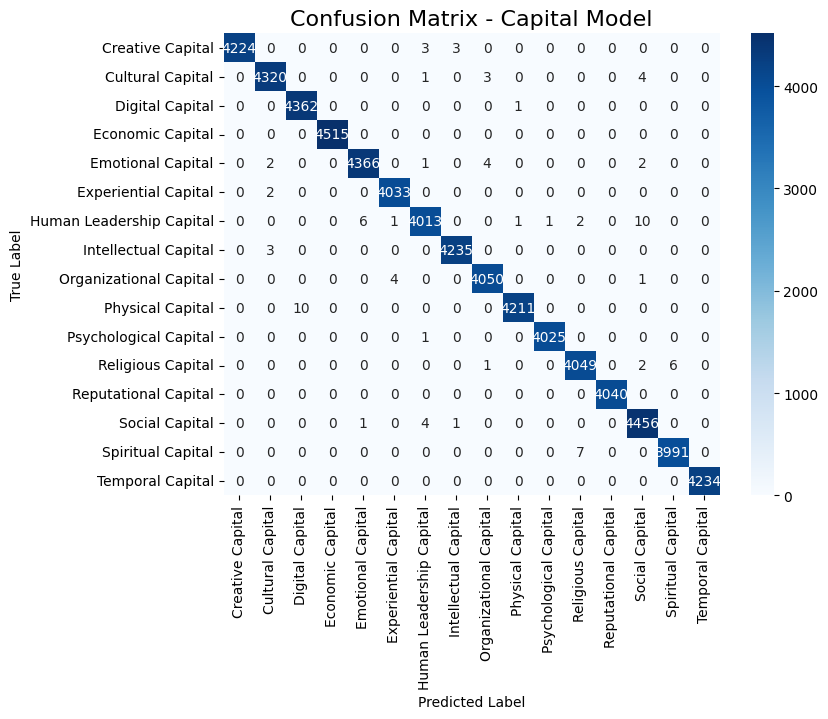

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
capital_pred = capital_model.predict(X_test)
capital_true = y_test['Capital']

# Class names
capital_classes = label_encoder_capital.inverse_transform(sorted(np.unique(capital_true)))

print("CAPITAL MODEL METRICS")
print("="*60)
print(f"Accuracy : {accuracy_score(capital_true, capital_pred):.4f}")
print(f"Precision (macro) : {precision_score(capital_true, capital_pred, average='macro'):.4f}")
print(f"Recall    (macro) : {recall_score(capital_true, capital_pred, average='macro'):.4f}")
print(f"F1-Score  (macro) : {f1_score(capital_true, capital_pred, average='macro'):.4f}\n")

print("Per-class Report:")
print(classification_report(capital_true, capital_pred, target_names=capital_classes))

# Confusion Matrix Plot
cm = confusion_matrix(capital_true, capital_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=capital_classes,
            yticklabels=capital_classes)
plt.title('Confusion Matrix - Capital Model', fontsize=16)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [16]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# === Custom Negation-Aware Preprocessor ===
class NegationAwarePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.negation_words = {'not', 'no', 'never', "n't", 'none', 'nobody', 'nothing', 'nowhere', 'neither', 'nor'}
    
    def _mark_negation(self, text):
        """Replace words in negated context with 'NOT_' prefix"""
        words = text.split()
        in_negation = False
        result = []
        
        for word in words:
            stripped = word.strip('.,!?;:"()[]{}')
            lower = stripped.lower()
            
            if lower in self.negation_words:
                in_negation = True
                result.append(word)
                continue
            elif any(punct in word for punct in '.!?;') and in_negation:
                in_negation = False
            
            if in_negation and stripped:
                # Attach NOT_ only to meaningful words (avoid pure punctuation)
                if lower not in {'not', "n't", 'no'}:
                    result.append(f"NOT_{word}")
                else:
                    result.append(word)
            else:
                result.append(word)
                
        return " ".join(result)
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        if isinstance(X, str):
            return [self._mark_negation(X)]
        return [self._mark_negation(text) for text in X]

# === Full Pipeline ===
sentiment_pipeline = Pipeline([
    ('negation_preprocessor', NegationAwarePreprocessor()),
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('classifier', CalibratedClassifierCV(
        LogisticRegression(
            C=4.0,
            class_weight='balanced',
            solver='lbfgs',
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        ),
        method='sigmoid',
        cv=5
    ))
])

# === Training ===
print("Fitting full sentiment analysis pipeline with negation handling...")
sentiment_pipeline.fit(X_train, y_train['Sentiment Label'])

print(f"\nModel Trained Successfully!")
train_acc = sentiment_pipeline.score(X_train, y_train['Sentiment Label'])
test_acc  = sentiment_pipeline.score(X_test, y_test['Sentiment Label'])

print(f"   Train Accuracy: {train_acc:.4f}")
print(f"   Test Accuracy : {test_acc:.4f}")

# === Negation Handling Test ===
test_sentences = [
    "i am sad",
    "i am not sad",
    "this movie is bad",
    "this movie is not bad",
    "he is a bad boy",
    "he is not a bad boy",
    "she is tired",
    "she is not tired",
    "It's not bad, actually pretty good",
     "It's bad, actually pretty not good",
]

print("\n=== Negation Handling Test ===")
predictions = sentiment_pipeline.predict(test_sentences)
probabilities = sentiment_pipeline.predict_proba(test_sentences).max(axis=1)

for sentence, pred, prob in zip(test_sentences, predictions, probabilities):
    print(f"{sentence:35} → {pred:<8} (confidence: {prob:.3f})")



Fitting full sentiment analysis pipeline with negation handling...

Model Trained Successfully!
   Train Accuracy: 0.9973
   Test Accuracy : 0.9964

=== Negation Handling Test ===
i am sad                            → 0        (confidence: 0.894)
i am not sad                        → 1        (confidence: 0.664)
this movie is bad                   → 0        (confidence: 1.000)
this movie is not bad               → 1        (confidence: 0.687)
he is a bad boy                     → 0        (confidence: 1.000)
he is not a bad boy                 → 1        (confidence: 0.664)
she is tired                        → 0        (confidence: 0.713)
she is not tired                    → 1        (confidence: 0.664)
It's not bad, actually pretty good  → 1        (confidence: 0.664)
It's bad, actually pretty not good  → 0        (confidence: 1.000)



          DETAILED SENTIMENT ANALYSIS EVALUATION
Accuracy        : 0.9964
Precision       : 0.9964
Recall          : 0.9964
F1-Score        : 0.9964


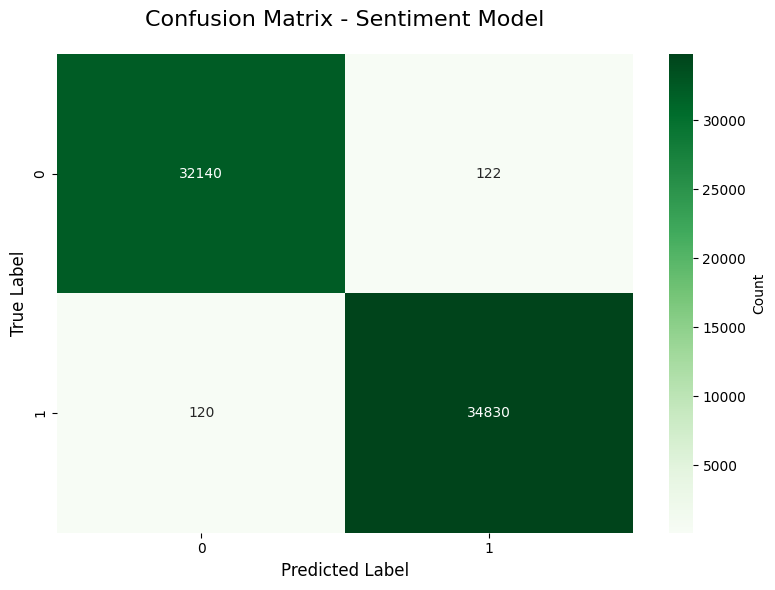

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Predictions on Test Set ===
y_test_pred = sentiment_pipeline.predict(X_test)
y_test_proba = sentiment_pipeline.predict_proba(X_test)[:, 1]  # Probability of positive class

# Assuming your labels are 'negative'/'positive' or 0/1
# Adjust if your labels are different (e.g., -1/0/1)
labels = sorted(y_test['Sentiment Label'].unique())

# === Comprehensive Metrics ===
print("\n" + "="*60)
print("          DETAILED SENTIMENT ANALYSIS EVALUATION")
print("="*60)

print(f"Accuracy        : {accuracy_score(y_test['Sentiment Label'], y_test_pred):.4f}")
print(f"Precision       : {precision_score(y_test['Sentiment Label'], y_test_pred, average='weighted'):.4f}")
print(f"Recall          : {recall_score(y_test['Sentiment Label'], y_test_pred, average='weighted'):.4f}")
print(f"F1-Score        : {f1_score(y_test['Sentiment Label'], y_test_pred, average='weighted'):.4f}")



# === Confusion Matrix (Pretty Plot) ===
cm = confusion_matrix(y_test['Sentiment Label'], y_test_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels,
            yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Sentiment Model', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()



In [18]:
with open('capital_model.pkl', 'wb') as f:
    pickle.dump(capital_model, f)
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(sentiment_pipeline, f)
with open('label_encoder_capital.pkl', 'wb') as f:
    pickle.dump(label_encoder_capital, f)
with open('label_encoder_sentiment.pkl', 'wb') as f:
    pickle.dump(label_encoder_sentiment, f)

print("Models and artifacts saved successfully (SVM-based capital model, LR-based sentiment model).")

Models and artifacts saved successfully (SVM-based capital model, LR-based sentiment model).


In [19]:
# FIXED PREDICTION FUNCTION – Works perfectly in GUI
def predict_pipeline(text):
    # Minimal cleaning only (remove HTML, special chars)
    clean_text = remove_unnecessary_characters(text)
    
    # Capital model handles everything internally
    capital_pred_encoded = capital_model.predict([clean_text])
    capital_pred = label_encoder_capital.inverse_transform(capital_pred_encoded)
    
    # Sentiment model handles negation + TF-IDF internally
    sentiment_pred_encoded = sentiment_pipeline.predict([clean_text])
    sentiment_pred = label_encoder_sentiment.inverse_transform(sentiment_pred_encoded)
    
    return capital_pred, sentiment_pred

In [20]:
# COMPLETE & CORRECTED GUI – Works 100% with your trained models
import tkinter as tk
from tkinter import messagebox, Text, Scrollbar, END

def predict_gui():
    text = entry.get("1.0", END).strip()  # Supports multi-line input
    if not text:
        messagebox.showwarning("Input Error", "Please enter a sentence!")
        return
    
    try:
        capital, sentiment = predict_pipeline(text)
        result_text = f"Predicted Capital:     {capital}\n"
        result_text += f"Predicted Sentiment:   {sentiment}"
        
        # Show result in a nice message box
        messagebox.showinfo("Prediction Result", result_text)
        
        # Also display in the output box below
        output_box.delete("1.0", END)
        output_box.insert(END, f"Input: {text}\n\n")
        output_box.insert(END, result_text, "highlight")
        output_box.tag_config("highlight", foreground="#0066CC", font=("Helvetica", 11, "bold"))
        
    except Exception as e:
        messagebox.showerror("Error", f"Prediction failed:\n{str(e)}")

# Create GUI Window
root = tk.Tk()
root.title("Capitals & Sentiment Classifier")
root.geometry("700x500")
root.configure(bg="#f0f2f5")

# Title Label
title_label = tk.Label(root, text="Capitals and Sentiment Prediction", 
                       font=("Helvetica", 16, "bold"), bg="#f0f2f5", fg="#1a1a1a")
title_label.pack(pady=15)

# Input Section
input_frame = tk.Frame(root, bg="#f0f2f5")
input_frame.pack(pady=10, padx=20, fill="x")

tk.Label(input_frame, text="Enter your sentence(s):", font=("Helvetica", 11), bg="#f0f2f5").pack(anchor="w")

entry = Text(input_frame, height=6, width=80, font=("Helvetica", 10), wrap="word", relief="solid", bd=1)
entry.pack(pady=8)

# Predict Button
predict_button = tk.Button(root, text="Predict Capital & Sentiment", command=predict_gui,
                           font=("Helvetica", 12, "bold"), bg="#0066CC", fg="white", 
                           activebackground="#0052a3", height=2, width=30)
predict_button.pack(pady=15)

# Output Section
output_frame = tk.Frame(root, bg="#f0f2f5")
output_frame.pack(pady=10, padx=20, fill="both", expand=True)

tk.Label(output_frame, text="Prediction Result:", font=("Helvetica", 11, "bold"), bg="#f0f2f5").pack(anchor="w")

output_box = Text(output_frame, height=10, font=("Helvetica", 10), bg="white", relief="solid", bd=1)
scrollbar = Scrollbar(output_frame, command=output_box.yview)
output_box.configure(yscrollcommand=scrollbar.set)

output_box.pack(side="left", fill="both", expand=True)
scrollbar.pack(side="right", fill="y")

# Footer
footer = tk.Label(root, text="Powered by SVM (Capitals) + Logistic Regression (Sentiment)", 
                  font=("Helvetica", 9), bg="#f0f2f5", fg="gray")
footer.pack(side="bottom", pady=10)

# Start GUI
root.mainloop()